<a href="https://colab.research.google.com/github/therokitoki/AA2_TP_Alsop-Hachen-Nemeth/blob/main/TP2/TP2_ejercicio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Practico N°2 AAII

Alumnos: Agustin Alsop, Rocio Hachen, Ulises Nemeth

## Ejercicio 1

### Descripción:
En este problema, se presenta un conjunto de datos que contiene clips de audio correspondientes a dígitos hablados del 0 al 9.

### Dataset:
https://www.tensorflow.org/datasets/catalog/spoken_digit

El dataset proporcionado incluye un total de 2500 clips de audio correspondientes a 5 locutores distintos, 50 clips por dígito por locutor.

### Objetivo:
Utilizando el dataset proporcionado, el objetivo es construir un modelo de clasificación utilizando redes neuronales que pueda inferir con precisión el dígito correspondiente dado un clip de audio. Se deben entrenar y evaluar modelos utilizando técnicas adecuadas de validación y métricas de evaluación de clasificación.

Se solicita entrenar dos modelos de distintas arquitecturas y comparar los resultados:
Modelo convolucional sobre los espectrogramas de los clips.
Modelo recurrente sobre los espectrogramas de los clips.

Ver https://colab.research.google.com/github/FCEIA-AAII/lab11/blob/master/lab11-a.ipynb como ejemplo de obtención de espectrogramas a partir de clips de audio.

### Entrega:
Código fuente de la solución implementada en Google Colab, que incluya:
- Análisis previo y preprocesamiento del set de datos.
- Definición y entrenamiento del modelo.
- Resultados de la evaluación de los modelos, incluyendo métricas de desempeño y visualizaciones relevantes.

Nota: el código debe estar debidamente documentado con comentarios explicativos para que el trabajo sea fácilmente comprensible para otros revisores.


# Preparación del entorno

In [1]:
!pip install -U tensorflow-datasets

## Librerias

In [2]:
import os
import pathlib
import time

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

import soundfile as sf
from collections import defaultdict
import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Preparación del entorno

In [3]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que TensorFlow asigne memoria dinámicamente
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Especificar la GPU por defecto
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Manejar error
        print(e)

1 Physical GPUs, 1 Logical GPUs


# Descarga de dataset

In [4]:
# Cargar dataset
ds = tfds.load('spoken_digit', split='train', as_supervised=False)
data = list(tfds.as_numpy(ds))

#print(ds.info.features)

# Agrupar los dígitos por hablante
speaker_digits = defaultdict(set)

for ex in data:
    label = int(ex['label'])
    filename = ex['audio/filename'].decode()
    speaker = filename.split('_')[1]
    speaker_digits[speaker].add(label)
print(" \n \n ")

# Verificamos que cada locutor haya dicho todos los dígitos.
for speaker, digits in speaker_digits.items():
    missing = set(range(10)) - digits
    if missing:
        print(f"🔴 {speaker} dijo {sorted(digits)} (faltan: {sorted(missing)})")
    else:
        print(f"🟢 {speaker} dijo TODOS los dígitos")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/spoken_digit/incomplete.4S7II6_1.0.9/spoken_digit-train.tfrecord*...:   0%…

Dataset spoken_digit downloaded and prepared to /root/tensorflow_datasets/spoken_digit/1.0.9. Subsequent calls will reuse this data.
 
 
 
🟢 nicolas dijo TODOS los dígitos
🟢 theo dijo TODOS los dígitos
🟢 yweweler dijo TODOS los dígitos
🟢 george dijo TODOS los dígitos
🟢 jackson dijo TODOS los dígitos


# Preparación de datos

In [5]:
# Crear estructura para almacenar audios por persona y clase
data = defaultdict(lambda: defaultdict(list))

for example in tfds.as_numpy(ds):
    audio = example['audio']
    label = int(example['label'])
    filename = example['audio/filename'].decode()  # ejemplo: '0_jackson_0.wav'
    speaker = filename.split('_')[1]

    data[speaker][label].append((filename, audio))

# Carpetas de salida
output_root = 'spoken_digit_split'

if not os.path.isdir(output_root):
  splits = ['train', 'val']
  for split in splits:
      for label in range(10):
          path = os.path.join(output_root, split, str(label))
          os.makedirs(path, exist_ok=True)

  # Dividir y guardar
  for speaker, digits in data.items():
      for digit, files in digits.items():
          random.shuffle(files)
          n = len(files)
          split_idx = int(0.8 * n) # 80-20

          train_files = files[:split_idx]
          val_files = files[split_idx:]

          for split, split_files in zip(['train', 'val'], [train_files, val_files]):
              for filename, audio in split_files:
                  audio = audio.astype(np.int16)  # Evitar error de tipo
                  path = os.path.join(output_root, split, str(digit), f"{speaker}_{filename}")
                  sf.write(path, audio, samplerate=8000, subtype='PCM_16')


Para que no haya sesgo con ningun dígito ni con ningun tipo de voz, queremos que tanto 'train' como 'val' contengan audios de cada persona diciendo cada dígito la misma cantidad de veces.

In [6]:
train_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='spoken_digit_split/train',
    batch_size=64,
    output_sequence_length=8000,
)

val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='spoken_digit_split/val',
    batch_size=64,
    output_sequence_length=8000,
    shuffle=False
)

label_names = np.array(train_ds.class_names)
num_classes = len(label_names)

Found 2000 files belonging to 10 classes.
Found 500 files belonging to 10 classes.


# Análisis exploratorio

In [7]:
train_ds.element_spec

(TensorSpec(shape=(None, 8000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [8]:
print(f"Número de clases: {num_classes}")
print("label names:", label_names)

Número de clases: 10
label names: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [9]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 8000, 1)
(64,)


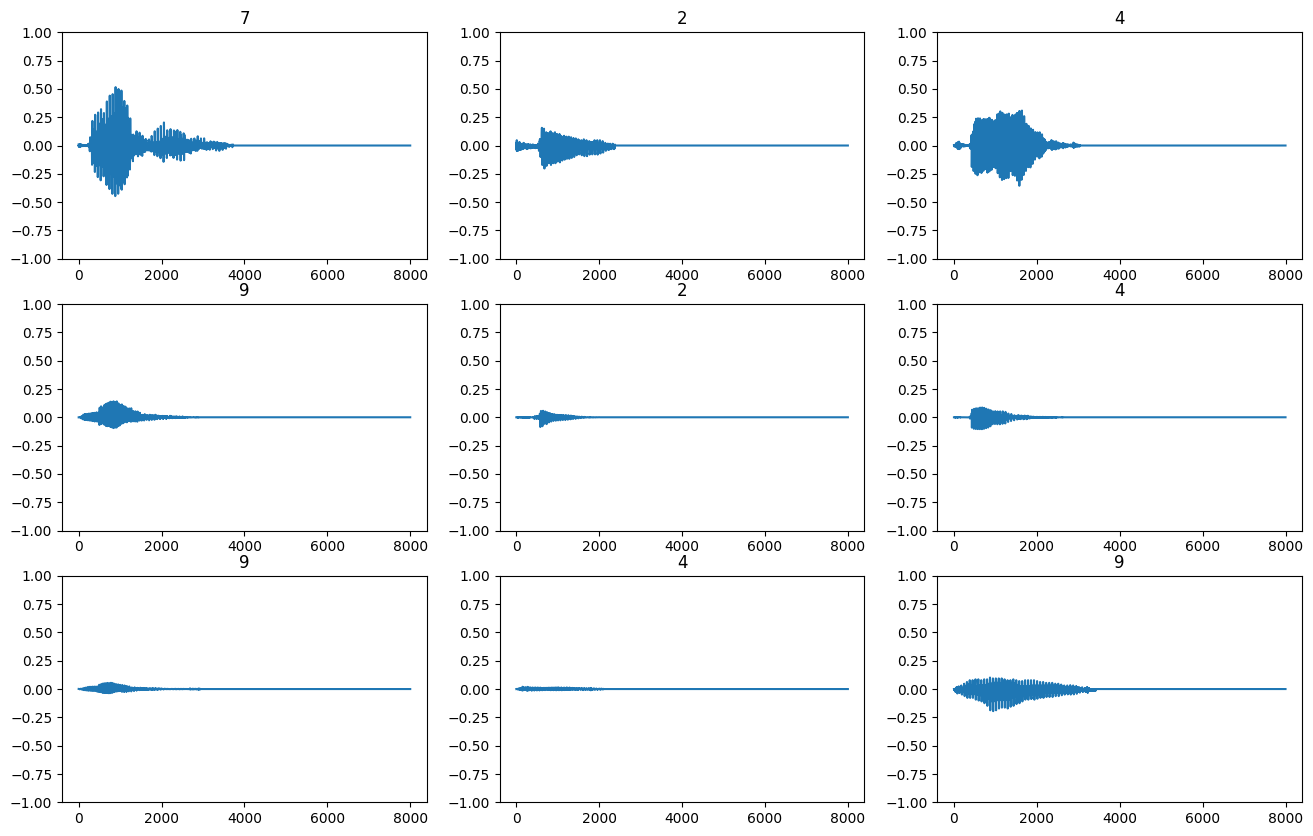

In [10]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  #plt.yticks(np.arange(-7000, 0, 7000))
  plt.ylim([-1, 1])

Observamos que no siempre se utiliza toda la duracion del audio para decir el numero

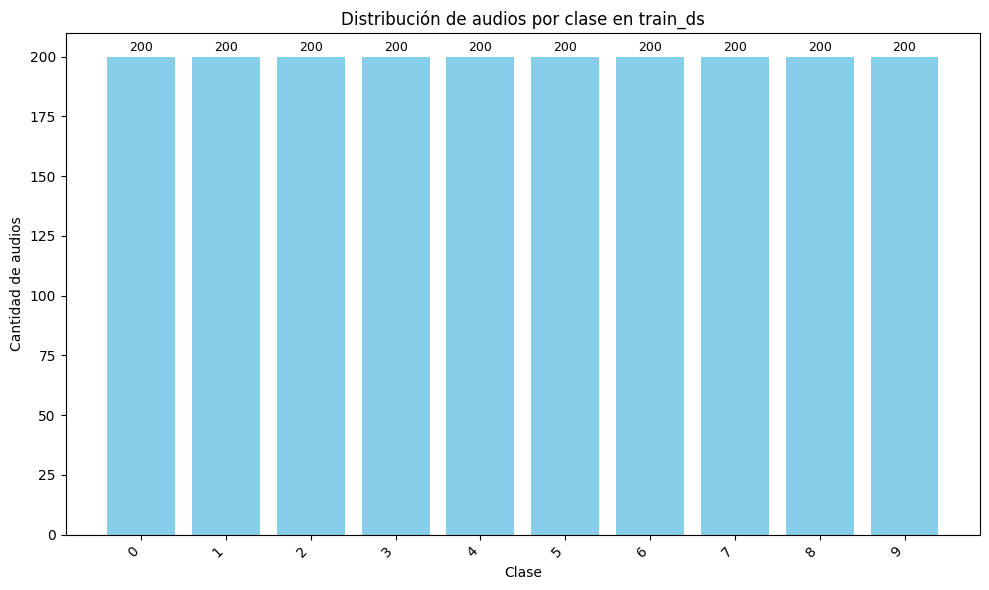

In [11]:
# Inicializamos contador
cant_clases = {name: 0 for name in train_ds.class_names}

# Recorremos el dataset
for audio, labels in train_ds:
    for label in labels.numpy():  # Convertimos a numpy para facilidad
        class_name = train_ds.class_names[label]
        cant_clases[class_name] += 1

# Visualización
plt.figure(figsize=(10, 6))
bars = plt.bar(cant_clases.keys(), cant_clases.values(), color='skyblue')
plt.xlabel("Clase")
plt.ylabel("Cantidad de audios")
plt.title("Distribución de audios por clase en train_ds")
plt.xticks(rotation=45, ha='right')

# Mostrar los valores arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, str(int(yval)),
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Podemos observar como el dataset esta totalmente balanceado

# Espectograma

Como el modelo espera un input de forma (batch, 8000), y nuestra data tiene forma (batch, 8000, 1), debemos quitar la última dimensión del tensor de audio que es de tamaño 1.

In [12]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 8000)
(64,)


In [13]:
def get_spectrogram(waveform):
  # Convierte la onda de sonido a un espectograma
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)

  spectrogram = tf.abs(spectrogram)
  # Se agrega una dimension "canales" para que el espectograma pueda ser utilizado como input en capas convolucionales
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

In [14]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Etiqueta:', label)
  print('Forma de la onda:', waveform.shape)
  print('Forma del espectograma:', spectrogram.shape)
  print('Reproducción del audio:')
  display.display(display.Audio(waveform, rate=8000))

Etiqueta: 3
Forma de la onda: (8000,)
Forma del espectograma: (61, 129, 1)
Reproducción del audio:


Etiqueta: 6
Forma de la onda: (8000,)
Forma del espectograma: (61, 129, 1)
Reproducción del audio:


Etiqueta: 8
Forma de la onda: (8000,)
Forma del espectograma: (61, 129, 1)
Reproducción del audio:


In [15]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

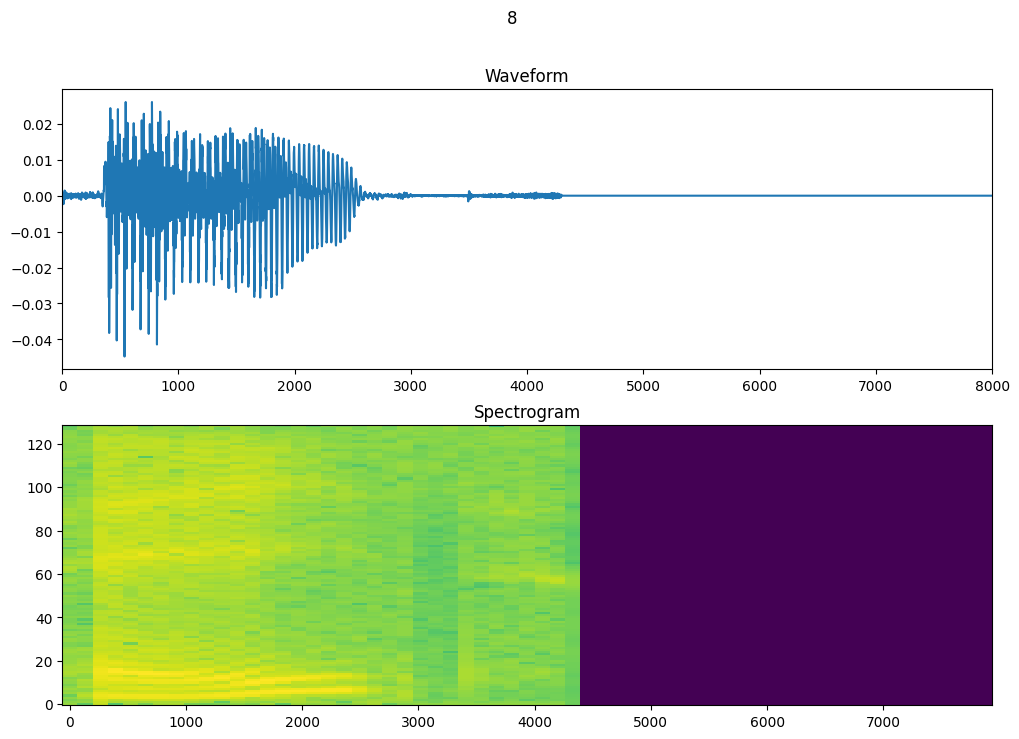

In [16]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 8000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

Si bien no podemos pretender obtener una comparativa entre el espectograma y el plot, se observa que la sección de audio sin frecuencia esta en violeta.

In [17]:
def make_spec_ds(ds):
  # Genera espectogramas para un dataset entero
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [18]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)

In [19]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

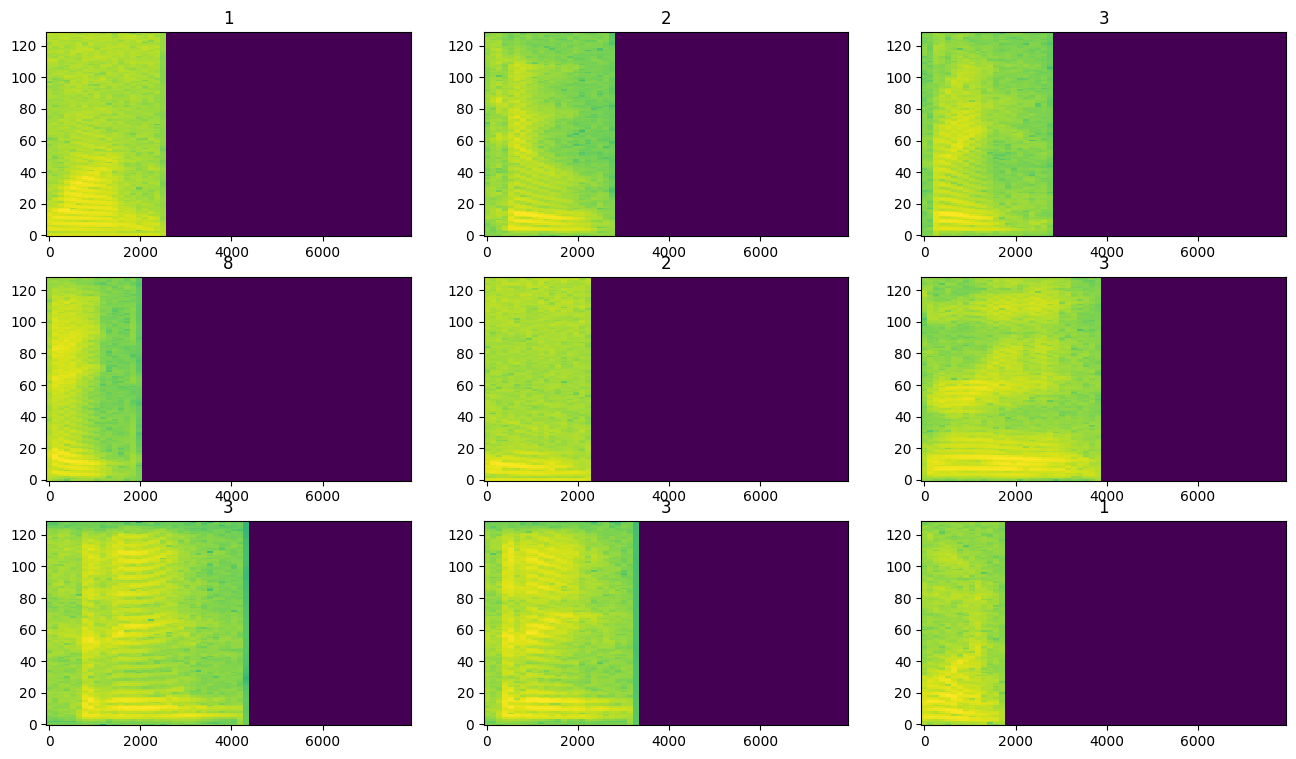

In [20]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

In [21]:
# Cache - guarda los datos en memoria lo que agiliza el tiempo de entrenamiento
# Shuffle - Baraja aleatoriamente los datos
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

# Modelos

## Modelo con Convulcionales

### Definición del modelo

In [22]:
example_spectrograms.shape

TensorShape([64, 61, 129, 1])

In [23]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Definimos la capa de normalización por separado para luego poder adaptarla.
norm_layer = layers.Normalization()
# Adapta el estado de la capa a los espectogramas
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model_cnn = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Resizing(32, 32),

    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model_cnn.summary()

Input shape: (61, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,869 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

### Compilación

In [24]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

### Entrenamiento

In [25]:
EPOCHS = 50
history_cnn = model_cnn.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.2528 - loss: 2.0856 - val_accuracy: 0.6080 - val_loss: 1.2781
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5554 - loss: 1.3491 - val_accuracy: 0.7640 - val_loss: 0.9390
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6518 - loss: 1.0635 - val_accuracy: 0.8260 - val_loss: 0.6974
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7097 - loss: 0.8206 - val_accuracy: 0.8940 - val_loss: 0.5227
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7699 - loss: 0.7292 - val_accuracy: 0.8940 - val_loss: 0.4195
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8198 - loss: 0.5576 - val_accuracy: 0.9200 - val_loss: 0.3754
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8724 - loss: 0.4416 - val_accuracy: 0.9220 - val_loss: 0.2917
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8404 - loss: 0.4734 - val_accuracy: 0.9360 - val_los

### Desempeño

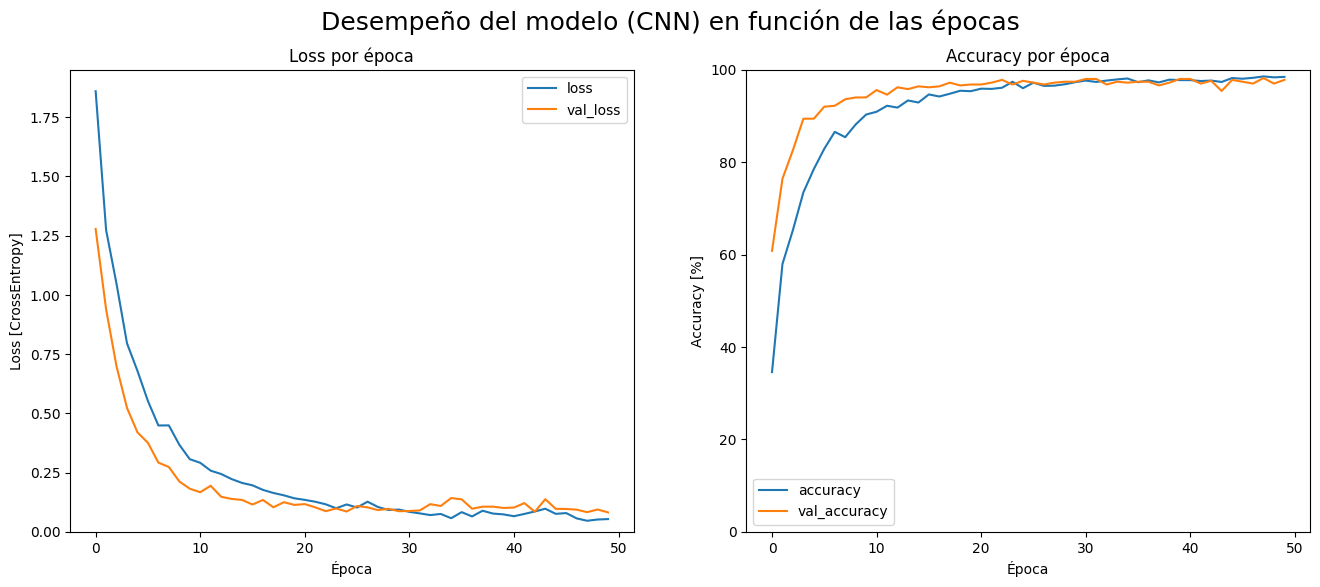

In [45]:
metrics = history_cnn.history

plt.figure(figsize=(16,6))
plt.suptitle('Desempeño del modelo (CNN) en función de las épocas', fontsize=18)

plt.subplot(1,2,1)
plt.plot(history_cnn.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Época')
plt.ylabel('Loss [CrossEntropy]')
plt.title('Loss por época')

plt.subplot(1,2,2)
plt.plot(history_cnn.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Época')
plt.ylabel('Accuracy [%]')
plt.title('Accuracy por época')
plt.show()

In [50]:
print("Accuracy de entrenamiento:", round(history_cnn.history['accuracy'][-1],3))
print("Accuracy de validación:", round(history_cnn.history['val_accuracy'][-1],3))

Accuracy de entrenamiento: 0.984
Accuracy de validación: 0.978


- La loss tanto de entrenamiento como de validación disminuye de manera consistente en las primeras épocas.

- Alrededor de la época 30, el Accuracy parece estabilizarse, por lo que no es probable que aumentar las épocas resultaría en una mejora del rendimiento.

- La val_loss y la val_accuracy siguen de cerca a las curvas de entrenamiento, sin una brecha pronunciada entre ellas, por lo que podemos concluir que el modelo no está sobreajustado.

### Predicción y matriz de confusión

In [27]:
y_pred = model_cnn.predict(val_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


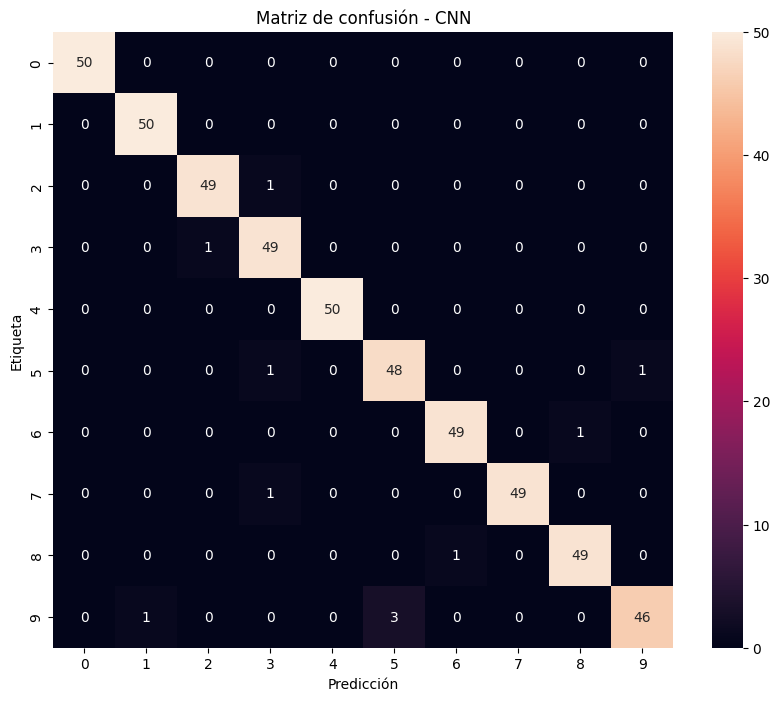

In [28]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta')
plt.title('Matriz de confusión - CNN')
plt.show()

El modelo CNN alcanzó una Accuracy de validación del 97%, y como muestra la matriz de confusión, la mayoría de las predicciones fueron correctas. Refleja una alta precisión general.

El dígito que presentó mayor cantidad de errores fue el 9, el cual fue predicho incorrectamente como 1 en una ocasión y como 5 en tres ocasiones.

## Modelo con Recurrentes

### Definición del modelo

In [29]:
input_shape = example_spectrograms.shape[1:]  # (time_steps, freq_bins, 1)

print('Input shape:', input_shape)
num_labels = len(label_names)

# Normalización
norm_layer = layers.Normalization()
norm_layer.adapt(data=train_spectrogram_ds.map(lambda spec, label: spec))

model_rnn = models.Sequential([
    layers.Input(shape=input_shape),
    norm_layer,

    # Aplanamos el eje de frecuencia y dejamos el de tiempo para la RNN
    layers.Reshape((input_shape[0], input_shape[1])),

    # RNNs
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),

    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_labels),
])

model_rnn.summary()

Input shape: (61, 129, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 61, 129, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 61, 129)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 61, 128)        │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,949 (843.55 KB)

 Trainable params: 215,946 (843.54 KB)

 Non-trainable params: 3 (16.00 B)

### Compilación

In [30]:
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

### Entrenamiento

In [31]:
EPOCHS = 50
history_rnn = model_rnn.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    #callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.2176 - loss: 2.1565 - val_accuracy: 0.6180 - val_loss: 1.3015
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5946 - loss: 1.1713 - val_accuracy: 0.8380 - val_loss: 0.5471
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8166 - loss: 0.5772 - val_accuracy: 0.8780 - val_loss: 0.3263
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8751 - loss: 0.3856 - val_accuracy: 0.9120 - val_loss: 0.2302
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9424 - loss: 0.2008 - val_accuracy: 0.9480 - val_loss: 0.1366
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9589 - loss: 0.1623 - val_accuracy: 0.9380 - val_loss: 0.1585
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9505 - loss: 0.1659 - val_accuracy: 0.9600 - val_loss: 0.1268
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9650 - loss: 0.1240 - val_accuracy: 0.9280 - v

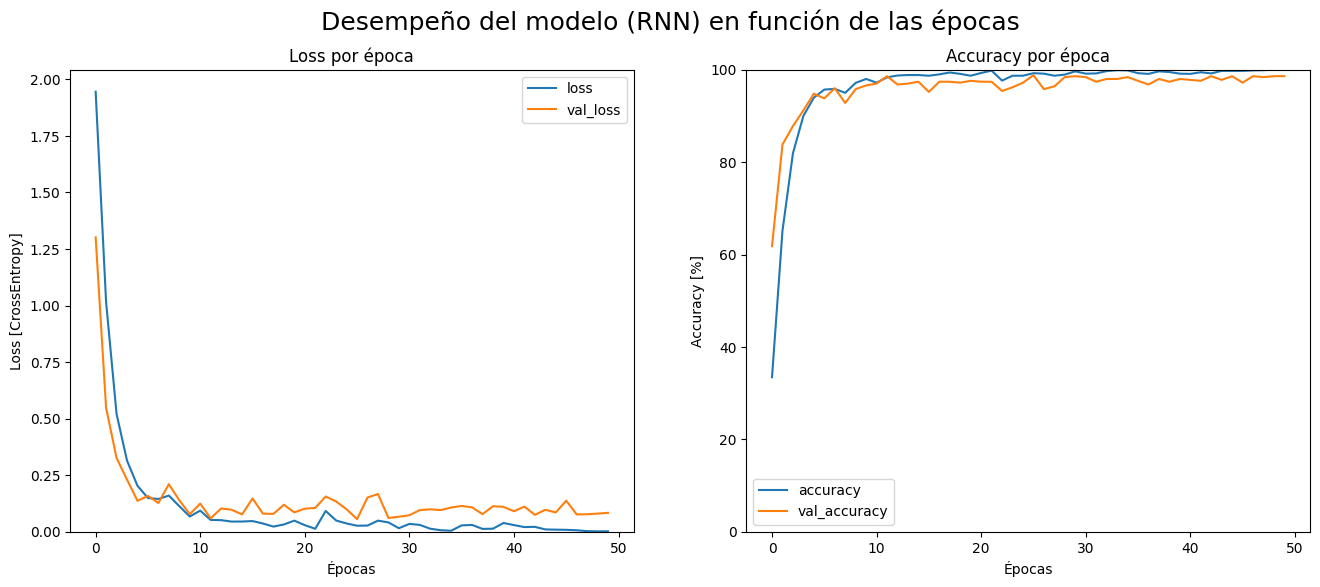

In [44]:
metrics = history_rnn.history
plt.figure(figsize=(16,6))
plt.suptitle('Desempeño del modelo (RNN) en función de las épocas', fontsize=18)

plt.subplot(1,2,1)
plt.plot(history_rnn.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Épocas')
plt.ylabel('Loss [CrossEntropy]')
plt.title('Loss por época')

plt.subplot(1,2,2)
plt.plot(history_rnn.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Épocas')
plt.ylabel('Accuracy [%]')
plt.title('Accuracy por época')
plt.show()

In [52]:
print("Accuracy de entrenamiento:", round(history_rnn.history['accuracy'][-1],3))
print("Accuracy de validación:", round(history_rnn.history['val_accuracy'][-1],3))

Accuracy de entrenamiento: 0.999
Accuracy de validación: 0.986


- La loss tanto de entrenamiento como de validación disminuye de manera consistente en las primeras épocas. Val_loss presenta unas leves fluctuaciones, pero se mantiene relativamente estable y bajo.

- A partir de la época 30, las métricas de accuracy y loss tienden a estabilizarse tanto en entrenamiento como en validación. Aunque no hay una convergencia perfecta entre ambas curvas, se alcanza un val_accuracy de aproximadamente 0.98, por lo que extender las épocas probablemente no aportaría mejoras significativas.

- La val_loss y la val_accuracy siguen de cerca a las curvas de entrenamiento,y el val_accuracy llega a 0.98, lo que sugiere que el modelo no está sobreajustado y generaliza bien.

### Predicción y matriz de confusión

In [33]:
y_pred = model_rnn.predict(val_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


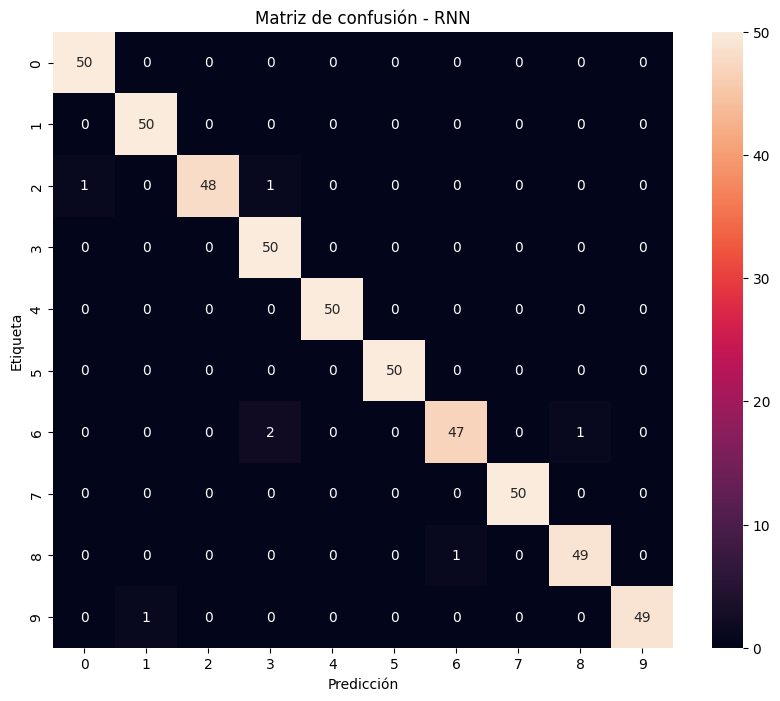

In [34]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta')
plt.title('Matriz de confusión - RNN')
plt.show()

Observamos que el modelo RNN logró una alta precisión de validación con un Accuracy de `98%`, lo que se refleja también en la matriz de confusión. La gran mayoría de los dígitos fueron correctamente clasificados, con una distribución casi perfecta a lo largo de la diagonal. Los errores de clasificación fueron mínimos y puntuales, observándose confusiones leves entre algunos dígitos como el 3 y el 6, o el 8 y el 6.

#Conclusiones

In [53]:
model_list = [model_cnn, model_rnn]
model_names = ['CNN', 'RNN']

results = []

for model, name in zip(model_list, model_names):
    # Evaluamos el modelo en todo el dataset
    loss, acc = model.evaluate(val_spectrogram_ds, verbose=0)

    # Medimos tiempo total de inferencia para todo el dataset
    samples = 0
    tiempo_total = 0.0

    for spectrogram_batch, label_batch in val_spectrogram_ds:
        batch_size = spectrogram_batch.shape[0]
        start_time = time.perf_counter()
        predictions = model(spectrogram_batch, training=False)
        end_time = time.perf_counter()

        batch_time = end_time - start_time
        tiempo_total += batch_time
        samples += batch_size

    avg_time_per_sample = tiempo_total / samples
    num_params = model.count_params()

    results.append({
        'Modelo': name,
        'Nro Parameteros': num_params,
        'Tiempo total inferencia (dataset)': tiempo_total,
        'Tiempo promedio por muestra': avg_time_per_sample,
        'Accuracy': acc
    })

df_results = pd.DataFrame(results)

In [39]:
df_results

,Modelo,Nro Parameteros,Tiempo total inferencia (dataset),Tiempo promedio por muestra,Accuracy
0,CNN,1625869,0.122403,0.000245,0.978
1,RNN,215949,0.285757,0.000572,0.986


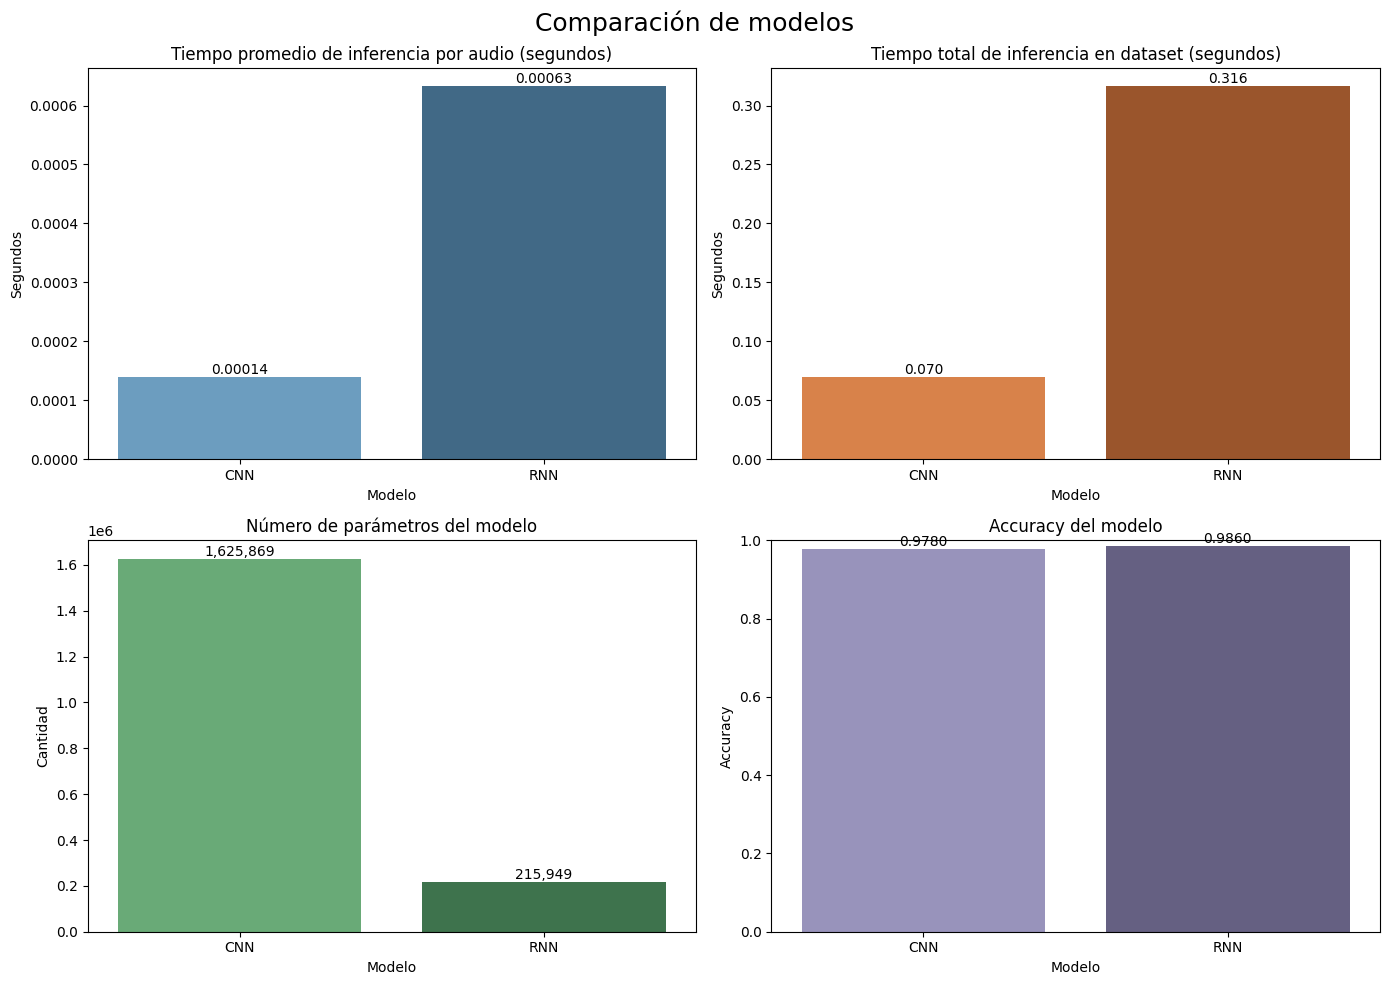

In [54]:
plt.figure(figsize=(14, 10))

plt.suptitle('Comparación de modelos', fontsize=18)

# Tiempo promedio por muestra
plt.subplot(2, 2, 1)
ax1 = sns.barplot(data=df_results, x="Modelo", y="Tiempo promedio por muestra", hue="Modelo", palette="Blues_d", dodge=False)
plt.title("Tiempo promedio de inferencia por audio (segundos)")
plt.ylabel("Segundos")
plt.xlabel("Modelo")
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width() / 2., height,
             f'{height:.5f}', ha="center", va="bottom")

# Tiempo total inferencia (dataset)
plt.subplot(2, 2, 2)
ax2 = sns.barplot(data=df_results, x="Modelo", y="Tiempo total inferencia (dataset)", hue="Modelo", palette="Oranges_d", dodge=False)
plt.title("Tiempo total de inferencia en dataset (segundos)")
plt.ylabel("Segundos")
plt.xlabel("Modelo")
for p in ax2.patches:
    height = p.get_height()
    ax2.text(p.get_x() + p.get_width() / 2., height,
             f'{height:.3f}', ha="center", va="bottom")

# Número de parámetros
plt.subplot(2, 2, 3)
ax3 = sns.barplot(data=df_results, x="Modelo", y="Nro Parameteros", hue="Modelo", palette="Greens_d", dodge=False)
plt.title("Número de parámetros del modelo")
plt.ylabel("Cantidad")
plt.xlabel("Modelo")
for p in ax3.patches:
    height = p.get_height()
    ax3.text(p.get_x() + p.get_width() / 2., height,
             f'{int(height):,}', ha="center", va="bottom")

# Accuracy
plt.subplot(2, 2, 4)
ax4 = sns.barplot(data=df_results, x="Modelo", y="Accuracy", hue="Modelo", palette="Purples_d", dodge=False)
plt.title("Accuracy del modelo")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.ylim(0, 1.0)
for p in ax4.patches:
    height = p.get_height()
    ax4.text(p.get_x() + p.get_width() / 2., height,
             f'{height:.4f}', ha="center", va="bottom")

plt.tight_layout()
plt.show()

Ambos modelos se destacan por su accuracy sobresaliente (98-99%), por lo que lo que definirá el "mejor modelo" serán las condiciones de trabajo que tengamos a disposición.

Si necesitamos un modelo que realice inferencias continuas y rápidas, el CNN será una mejor opción, ya que destaca sobre la RNN en velocidad de inferencia. Sin embargo, es un modelo mucho más grande, por lo que si queremos correrlo en dispositivos muy limitados, la RNN puede ser una mejor alternativa.

Falta

- Conclusiones
- Completar readme
- Comentar los graficos saludos
- Verificar el EDA